# Stage 10 — Validation and Context

Independent datasets, used to validate and contextualise the frozen model and **never as inputs to it**. Both were kept out of the vulnerability score from the start, to avoid the circularity that led to dropping the EPIK+rainfall framework: a score cannot be validated with the data that built it.

- **CFEV Groundwater Dependent Ecosystems (springs)** — the only independent hydrological check available: do known springs/GDEs sit in the more connected/susceptible parts of the karst?
- **CFEV Karst conservation value** — not validation (it measures something different from vulnerability), but context: where does land-use pressure risk coincide with conservation significance?

**Design of the GDE test:**
1. The null is built from **karst only** (karst polygon scores, weighted by area). A null built from the whole raster would mostly detect that karst scores higher than non-karst.
2. GDE points are compared against **intrinsic vulnerability** (susceptibility × connectivity), not final risk. Land-use pressure has no plausible causal link to where a spring occurs.
3. A spring counts as **on karst** if it is within 500 m of a karst polygon, and takes the score of its nearest polygon. Springs emerge at karst margins and the Atlas polygons are coarse, so the raster cell under a point is often just outside the karst. Scoring those springs as zero, against a null that contains only karst, biases the test against the model. The distance is varied from 0 to 1000 m below.
4. GDE points are heavily clustered (all Mole Creek points are nearest to one named system; 112 statewide points reduce to ~25 systems), so replication is at the **system level**, not the point level.
5. Warm and mound springs have no obvious relationship to karst connectivity, so the test is repeated on tufa, cold and subsurface-stream types only.

**Correction note:** an earlier version of this stage sampled the raster cell under each point. That scored off-karst springs as zero against a karst-only null and wrongly concluded that springs sit below typical karst. The version below replaces it.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, str(Path("..") / "src"))
from karst import add_karst_susceptibility, add_connectivity, in_mole_creek_focus

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
inpath = data / "Input_data"
outpath = data / "Output_data"

GDE_MAX_DIST_M = 500  # a spring counts as "on karst" if within this distance of a karst polygon

def permutation_percentile(values, actual_mean, n_sample, weights=None, n_perm=10000, seed=42):
    """Percentile of `actual_mean` in a null of `n_perm` random draws of `n_sample` values
    (probability-weighted by `weights`, e.g. polygon area)."""
    rng = np.random.default_rng(seed)
    p = None if weights is None else np.asarray(weights, float) / np.sum(weights)
    idx = rng.choice(len(values), size=(n_perm, n_sample), p=p)
    sample_means = np.asarray(values)[idx].mean(axis=1)
    return (sample_means < actual_mean).mean() * 100, sample_means

## 10.1 GDE springs — hydrological plausibility check

115 statewide GDE points (springs, subsurface streams) from CFEV.
**Never used to build the connectivity score** — `KPROXCATCH`, `KDISTCATCH` and exposure type were the inputs; this is the
first time these points have touched the model at all.

Tested against **intrinsic vulnerability** (susceptibility × connectivity,
before land-use pressure is applied) rather than final risk, and against
a null built from **karst cells only** — so this asks "do GDEs sit in the
more connected/susceptible parts of the karst?", not the much easier
question "is karst riskier than non-karst?" (true by construction, and
uninformative about the connectivity score specifically).

In [2]:
gde = gpd.read_file(inpath / "LIST_CFEV_GROUNDWATER_STATEWIDE/list_cfev_groundwater_statewide.shp").to_crs("EPSG:7855")
print("GDE types statewide:")
print(gde["GDE_TYPE"].value_counts())

mc_boundary = gpd.read_file(outpath / "mole_creek_bounding_box_EPSG7855.gpkg")
gde_mc = gpd.clip(gde, mc_boundary)
print(f"\nGDE points within Mole Creek: {len(gde_mc)} of {len(gde)} statewide")

GDE types statewide:
GDE_TYPE
Tufa-depositing spring    54
Cold spring               23
Subsurface stream         23
Warm spring                8
Mound spring               7
Name: count, dtype: int64

GDE points within Mole Creek: 37 of 115 statewide


### Mole Creek: descriptive only, not a permutation test

Of the 37 GDE points in the 3 km buffer, 36 are within 500 m of the Mole Creek karst, and **all 36 are nearest to the single system "Mole Creek."** A permutation test treats each point as an independent draw, so with one effective system a p-value from n = 36 would overstate the evidence by roughly 36-fold. The comparison is descriptive: the mean score at the springs against the area-weighted mean of the Mole Creek karst, with no p-value.

In [3]:
karst_mc_atlas = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc_atlas = karst_mc_atlas[karst_mc_atlas.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

# Only the Mole Creek karst itself counts; the 3 km buffer also holds neighbouring karst.
focus_polys = karst_mc_atlas[in_mole_creek_focus(karst_mc_atlas) & (karst_mc_atlas["karst_intensity"] > 0)].copy()
focus_polys["intrinsic"] = (focus_polys["karst_intensity"] / 4.0) * (focus_polys["connectivity"] / 3.0)
focus_polys["area"] = focus_polys.geometry.area

# Each spring takes the intrinsic score of its nearest Mole Creek karst polygon, if within GDE_MAX_DIST_M.
near = gpd.sjoin_nearest(gde_mc, focus_polys[["KNAME", "intrinsic", "geometry"]], how="left", distance_col="dist_m")
near = near[~near.index.duplicated(keep="first")]
on_karst = near[near["dist_m"] <= GDE_MAX_DIST_M]
print(f"GDE points in the 3 km buffer: {len(near)}; within {GDE_MAX_DIST_M} m of the Mole Creek karst: {len(on_karst)}")
print("\nBy nearest named system:")
print(on_karst["KNAME"].value_counts())

gde_mean = on_karst["intrinsic"].mean()
karst_mean = np.average(focus_polys["intrinsic"], weights=focus_polys["area"])
print(f"\nMean intrinsic vulnerability at GDE points:            {gde_mean:.3f}  (n={len(on_karst)})")
print(f"Mean intrinsic vulnerability, Mole Creek karst (area-weighted): {karst_mean:.3f}")

GDE points in the 3 km buffer: 37; within 500 m of the Mole Creek karst: 36

By nearest named system:
KNAME
Mole Creek    36
Name: count, dtype: int64

Mean intrinsic vulnerability at GDE points:            0.852  (n=36)
Mean intrinsic vulnerability, Mole Creek karst (area-weighted): 0.692


**Result:** Mole Creek's springs sit in karst that scores higher than the Mole Creek average (0.85 against 0.69). This is one system, so it cannot carry statistical weight on its own, but it points the same way as the statewide result below.

### Statewide: system-level test (not point-level)

The 112 statewide GDE points cluster into only **~25 distinct named karst systems** by nearest neighbour. The test is built around systems: one intrinsic-vulnerability value per system (the mean over its springs within the distance limit), compared against 10,000 random same-size draws of karst polygon scores, weighted by polygon area. It is repeated for distance limits of 0, 250, 500 and 1000 m, and for all spring types and the core types only.

In [4]:
tasmania = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    tas_nodata = src.nodata

karst_tas = gpd.read_file(inpath / "KarstAtlas/Karst_Ver_3_1/Karst_Atlas_v3_1.shp").to_crs("EPSG:7855")
karst_tas = karst_tas[karst_tas.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
add_karst_susceptibility(karst_tas)
add_connectivity(karst_tas)
karst_tas["intrinsic"] = (karst_tas["karst_intensity"] / 4.0) * (karst_tas["connectivity"] / 3.0)
kp = karst_tas[karst_tas["karst_intensity"] > 0][["KNAME", "intrinsic", "geometry"]].reset_index(drop=True)
kp["area"] = kp.geometry.area
print(f"Area-weighted mean intrinsic vulnerability of all mapped karst: {np.average(kp['intrinsic'], weights=kp['area']):.3f}")

gde_tas = gpd.clip(gde, tasmania)
near_tas = gpd.sjoin_nearest(gde_tas, kp[["KNAME", "intrinsic", "geometry"]], how="left", distance_col="dist_m")
near_tas = near_tas[~near_tas.index.duplicated(keep="first")]
print(f"\nDistance from each GDE point to the nearest karst polygon: median {near_tas['dist_m'].median():.0f} m, "
      f"{(near_tas['dist_m'] == 0).sum()} of {len(near_tas)} points fall inside a polygon")

core_types = ["Tufa-depositing spring", "Cold spring", "Subsurface stream"]

def system_test(points):
    """One value per nearest named system (mean over its springs), against a null of random
    same-size draws of karst polygon values, probability-weighted by polygon area."""
    by_system = points.groupby("KNAME")["intrinsic"].mean()
    pct, null = permutation_percentile(kp["intrinsic"].values, by_system.mean(), len(by_system), weights=kp["area"].values)
    return len(points), len(by_system), by_system.mean(), null.mean(), pct

rows = []
for label, subset in [("all spring types", near_tas), ("core types only", near_tas[near_tas["GDE_TYPE"].isin(core_types)])]:
    for dist in [0, 250, 500, 1000]:
        n_pts, n_sys, actual, null_mean, pct = system_test(subset[subset["dist_m"] <= dist])
        rows.append({"spring types": label, "within (m)": dist, "points": n_pts, "systems": n_sys,
                     "GDE mean": round(actual, 3), "karst null mean": round(null_mean, 3), "percentile": round(pct, 1)})
print("\nSystem-level test (one value per named system) against a karst-only, area-weighted null:")
print(pd.DataFrame(rows).to_string(index=False))

Area-weighted mean intrinsic vulnerability of all mapped karst: 0.591

Distance from each GDE point to the nearest karst polygon: median 77 m, 50 of 112 points fall inside a polygon

System-level test (one value per named system) against a karst-only, area-weighted null:
    spring types  within (m)  points  systems  GDE mean  karst null mean  percentile
all spring types           0      50       17     0.773            0.591        99.9
all spring types         250      70       22     0.722            0.591        99.5
all spring types         500      79       24     0.700            0.591        98.6
all spring types        1000      91       28     0.714            0.591        99.7
 core types only           0      39       12     0.804            0.591        99.9
 core types only         250      56       15     0.746            0.591        99.4
 core types only         500      64       17     0.731            0.591        99.3
 core types only        1000      76       22   

**Result: springs sit in higher-scoring karst than the average karst.** At a 500 m limit the 24 GDE systems average 0.70 against a karst null of 0.59, at about the 99th percentile of the null (98.6th for all types, 99.3rd for the core types). The result holds across the whole range of distance limits (98.6th to 99.9th percentile) and when warm and mound springs are removed. This is the independent signal the model needed: springs are more often found in the karst that the model scores as more susceptible and better connected, not just in karst rather than non-karst.

**Limitations:**
- **Few effective samples.** There are 12 to 28 systems depending on the distance limit, and Mole Creek is a single system.
- **Independence.** CFEV's GDE locations were likely mapped partly from existing karst and geological knowledge, the same knowledge that feeds the susceptibility and connectivity layers. The test is independent-ish, not a clean external validation.
- **Mapping effort.** Well-studied karst may be both more intensely categorised and more likely to have mapped springs, which would favour a positive result without the model being right.
- **Method history.** An unrestricted test (GDE points against the whole raster, all points independent) gave 11.5× background risk and p < 0.0001; that mostly reflected karst against non-karst. A first correction then went too far the other way by scoring off-karst springs as zero. The version above avoids both.

## 10.2 CFEV conservation value × risk priority matrix

Not validation — CFEV conservation value measures ecological/geological
significance, a different thing from land-use pressure vulnerability.
Combining them identifies **where pressure and significance coincide**,
which is the actionable output: a location with high risk but low
conservation value is a different management problem than one with
both high risk and high conservation value.

CFEV Karst uses different polygon boundaries from the Karst Atlas used
throughout this project (confirmed earlier: "Mole Creek" splits into
"Mole Creek 1-4" in CFEV) — joined here by spatial overlay, not by
name.

In [5]:
cfev = gpd.read_file(inpath / "LIST_CFEV_KARST_STATEWIDE/list_cfev_karst_statewide.shp").to_crs("EPSG:7855")
cfev = cfev[cfev.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
print(f"CFEV Karst polygons statewide: {len(cfev)}")
print(cfev["KT_ICV"].value_counts())  # Integrated Conservation Value: M/H/VH

CFEV Karst polygons statewide: 334
KT_ICV
M     186
H     128
VH     20
Name: count, dtype: int64


In [6]:
rows = []
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    for _, row in cfev.iterrows():
        out_image, _ = mask(src, [row.geometry], crop=True, nodata=tas_nodata)
        v = out_image[0]
        v = v[v != tas_nodata]
        rows.append({"KT_NAME": row["KT_NAME"], "KT_ICV": row["KT_ICV"],
                     "mean_risk": v.mean() if len(v) else np.nan, "n_pixels": len(v)})

cfev_risk = pd.DataFrame(rows)
print(f"CFEV polygons with a valid risk value: {cfev_risk['mean_risk'].notna().sum()} / {len(cfev_risk)}")
print(f"Polygons with fewer than 5 valid pixels: {(cfev_risk['n_pixels'] < 5).sum()}; "
      f"fewer than 10: {(cfev_risk['n_pixels'] < 10).sum()} -- these mean_risk values are unreliable (one or two 100m pixels).")
print(cfev_risk.groupby("KT_ICV")["mean_risk"].agg(["mean", "count"]))

CFEV polygons with a valid risk value: 328 / 334
Polygons with fewer than 5 valid pixels: 30; fewer than 10: 46 -- these mean_risk values are unreliable (one or two 100m pixels).
            mean  count
KT_ICV                 
H       0.144299    125
M       0.136259    183
VH      0.170267     20


**The conservation-value gradient is nearly flat** (0.218 Medium → 0.239 High → 0.277 Very High): the ordering is in the expected direction, but conservation value is not a strong predictor of modelled risk by this measure.

Risk class x Conservation value matrix (polygon counts):
KT_ICV          M   H  VH
risk_class               
Low risk       65  42   3
Moderate risk  67  37   5
High risk      51  46  12

Note: 'risk_class' is a tertile split of this exact set of polygons, so each class contains ~1/3 of all 328 polygons *by construction*, regardless of whether there's any real risk signal. It's a ranking device for the priority list below, not itself a finding.
cell_7:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


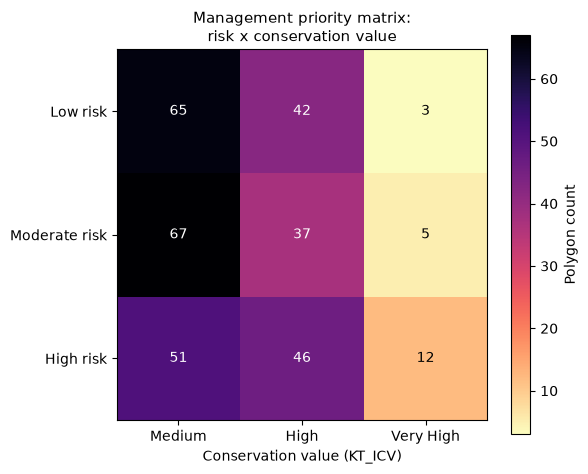

In [7]:
valid_cfev = cfev_risk.dropna(subset=["mean_risk"]).copy()
tertiles = valid_cfev["mean_risk"].quantile([1/3, 2/3]).values

def risk_class(r):
    if r <= tertiles[0]:
        return "Low risk"
    elif r <= tertiles[1]:
        return "Moderate risk"
    return "High risk"

valid_cfev["risk_class"] = valid_cfev["mean_risk"].apply(risk_class)
matrix = pd.crosstab(valid_cfev["risk_class"], valid_cfev["KT_ICV"])
matrix = matrix.reindex(index=["Low risk", "Moderate risk", "High risk"], columns=["M", "H", "VH"])
print("Risk class x Conservation value matrix (polygon counts):")
print(matrix)
print("\nNote: 'risk_class' is a tertile split of this exact set of polygons, so each class contains "
      "~1/3 of all 328 polygons *by construction*, regardless of whether there's any real risk signal. "
      "It's a ranking device for the priority list below, not itself a finding.")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matrix.values, cmap="magma_r")
ax.set_xticks(range(3)); ax.set_xticklabels(["Medium", "High", "Very High"])
ax.set_yticks(range(3)); ax.set_yticklabels(["Low risk", "Moderate risk", "High risk"])
for i in range(3):
    for j in range(3):
        ax.text(j, i, matrix.values[i, j], ha="center", va="center",
                color="white" if matrix.values[i, j] > matrix.values.max() / 2 else "black")
ax.set_xlabel("Conservation value (KT_ICV)")
ax.set_title("Management priority matrix:\nrisk x conservation value", fontsize=11)
plt.colorbar(im, label="Polygon count")
plt.tight_layout()
plt.show()

### Priority zones, with pixel counts and a minimum-size filter

Some of the top-ranked entries in an unfiltered list were polygons with only a handful of valid 100 m pixels (down to 2), so their `mean_risk` lands on round fractions (e.g. exactly 0.75 or 0.50) from averaging 4 or 2 pixels. The ranking therefore shows `n_pixels` and requires a minimum of 10 valid pixels (0.1 km²).

In [8]:
priority_all = valid_cfev[(valid_cfev["risk_class"] == "High risk") & (valid_cfev["KT_ICV"].isin(["H", "VH"]))]
priority_all = priority_all.sort_values("mean_risk", ascending=False)

priority_filtered = priority_all[priority_all["n_pixels"] >= 10]

print(f"Unfiltered: {len(priority_all)} of {len(valid_cfev)} polygons qualify as 'high risk + high/VH conservation value' "
      "-- but recall the tertile split guarantees roughly 1/3 of all polygons are 'High risk' regardless of signal, "
      "so this count is not itself evidence of anything; it's a ranking device.")
print(f"After requiring >= 10 valid pixels: {len(priority_filtered)} polygons remain "
      f"({len(priority_all) - len(priority_filtered)} dropped for being too small to trust)")

print("\nTop 15, size-filtered:")
print(priority_filtered[["KT_NAME", "mean_risk", "KT_ICV", "n_pixels"]].head(15).to_string(index=False))

priority_filtered.to_csv(outpath / "stage10_priority_zones.csv", index=False)

mole_creek_rows = cfev_risk[cfev_risk["KT_NAME"].str.contains("Mole Creek", na=False)]
print("\nMole Creek's own CFEV entries, for context:")
print(mole_creek_rows.to_string(index=False))

Unfiltered: 58 of 328 polygons qualify as 'high risk + high/VH conservation value' -- but recall the tertile split guarantees roughly 1/3 of all polygons are 'High risk' regardless of signal, so this count is not itself evidence of anything; it's a ranking device.
After requiring >= 10 valid pixels: 51 polygons remain (7 dropped for being too small to trust)

Top 15, size-filtered:
              KT_NAME  mean_risk KT_ICV  n_pixels
         Grim-Trefoil   0.364086      H        11
   Emita - Memana (2)   0.355044      H      7499
           Port Hills   0.351189      H        57
     Mt Stanley Creek   0.302197      H        14
         Mole Creek 2   0.289717     VH      4339
          McRae Hills   0.283725      H        16
     Fairview (Redpa)   0.270209      H       303
   Mount Ronald Cross   0.267668      H       443
City of Melbourne Bay   0.267180      H        14
            Bubs Hill   0.259821      H       147
                Ranga   0.258223      H      1504
       Whistler

**Result:** after filtering out undersized polygons, a double-digit number of named systems statewide combine high modelled risk with high/very-high conservation value. This is a ranked, actionable list distinct from the risk map alone. The exact count depends on the tertile cut and the pixel-count threshold, so treat it as a list to follow up on, not a precise statistic. Mole Creek's own CFEV entries (1-4) sit at VH conservation value with moderate risk, consistent with but not identical to the Karst-Atlas-based "Mole Creek" result from Stages 6-8, since CFEV uses different polygon boundaries.

## Not done here

TGD (Tasmanian Geoconservation Database) and KID (Karst Index Database) cross-checks were scoped as optional, time-permitting (scope doc, Stage 10). They were not built.

## Stage 10 summary

- **GDE validation:** with a karst-only null, intrinsic vulnerability rather than risk, springs valued at their nearest karst polygon, and system-level replication, springs sit in higher-scoring karst than average (about the 99th percentile statewide, across distance limits and spring types). Mole Creek has one effective system and is reported descriptively.
- **Independence:** CFEV GDE points are plausibly not fully independent of the karst and geology data used to build the model, and the number of effective samples is small (12 to 28 systems).
- **Conservation value:** the gradient is in the expected direction but nearly flat (0.218 / 0.239 / 0.277).
- **Priority zones:** a useful ranking tool, not a precise statistic. The count depends on a tertile split (which puts ~1/3 of polygons in "high risk") and on the minimum pixel-count filter.

## Stage 10 outputs

- `stage10_priority_zones.csv` — size-filtered statewide high-risk/high-conservation-value systems, with pixel counts

**Next:** write the Jupyter Book chapters (`introduction.md`, `methods.md`, `results.md`, `discussion.md`, `conclusion.md`, `reference.md`).